In [5]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from setuptools.command.rotate import rotate

In [3]:
df = pd.read_csv('./assets/cleaned_5G_smartphone.csv')

In [21]:
df

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,3120,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
1,1,OnePlus,Nord 6,38999,4.60,True,True,True,True,True,...,2772,Android,False,NaN,50,32,2,1,Snapdragon,8s gen4
2,2,Samsung,Galaxy S25 FE,44999,4.70,True,True,True,True,True,...,2340,Android,False,NaN,50,12,3,1,Exynos,2400
3,3,Vivo,T5x 5G,18999,4.10,True,True,True,True,True,...,2344,Android,False,NaN,50,32,2,1,Dimensity,7400 turbo
4,4,Infinix,Note 60 Pro 5G,31999,4.75,True,True,True,True,True,...,2644,Android,True,1024.0,50,13,2,1,Snapdragon,7s gen4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,897,Tecno,Spark 10 5G,13800,4.55,True,True,True,True,True,...,1612,Android,True,1024.0,50,8,2,1,Dimensity,6020
898,898,Xiaomi,Redmi Note 12,18499,4.20,True,True,True,True,True,...,2400,Android,True,1024.0,48,13,3,1,Snapdragon,4 gen 1
899,899,Realme,11,18999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,108,16,2,1,Dimensity,6100 plus
900,900,Motorola,Razr 40 Ultra,59990,4.20,True,True,True,True,True,...,2640,iOS,False,NaN,13,32,2,1,Snapdragon,8+ gen1


In [7]:
df['os'].value_counts()

os
Android v15      356
Android v14      242
Android v16      146
Android v13       69
Android v12       23
iOS v18           14
iOS v26           12
iOS v17            6
Android v11        6
iOS v26.3          2
iOS v16            2
iOS v14.0          2
Android v10.0      2
iOS v15            1
Android 15 Go      1
Android v10        1
Name: count, dtype: int64

In [11]:
df['os'] = df['os'].apply(lambda x: "Android" if "Android" in str(x) else "iOS")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pos                       902 non-null    int64  
 1   brand                     902 non-null    str    
 2   model                     902 non-null    str    
 3   price                     902 non-null    int64  
 4   rating                    902 non-null    float64
 5   Dual Sim                  902 non-null    bool   
 6   3G                        902 non-null    bool   
 7   4G                        902 non-null    bool   
 8   5G                        902 non-null    bool   
 9   VoLTE                     902 non-null    bool   
 10  Vo5G                      902 non-null    bool   
 11  Wi-Fi                     902 non-null    bool   
 12  NFC                       902 non-null    bool   
 13  IR Blaster                902 non-null    bool   
 14  processor_core       

In [20]:
df.isnull().sum()

pos                           0
brand                         0
model                         0
price                         0
rating                        0
Dual Sim                      0
3G                            0
4G                            0
5G                            0
VoLTE                         0
Vo5G                          0
Wi-Fi                         0
NFC                           0
IR Blaster                    0
processor_core                0
processor_speed_in_GHz       37
Ram                           0
storage                       0
battery_capacity              0
is_fast_charging              0
fast_charging_capacity       52
display_size                  0
display_refresh_rate         38
camera_notch_type             8
pixel_width                   0
pixel_height                  0
os                            0
is_memory_card_supported      0
max_card_gb                 610
primary_rear_mp               0
primary_front_mp              0
num_rear

## brand column univariate analysis
- Realme > Vivo = Samsung are the three dominating companies

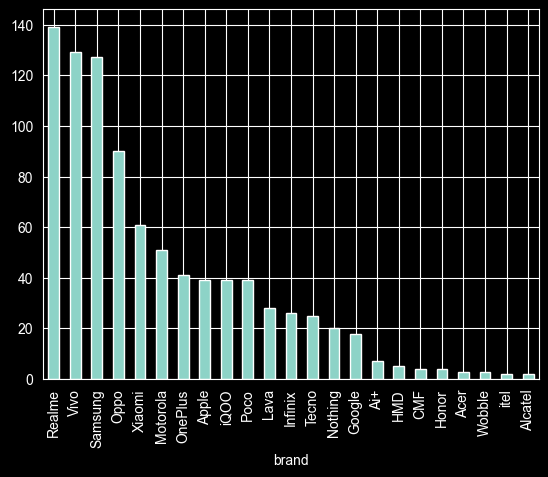

In [29]:
df['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/brand/bar_plot.png')


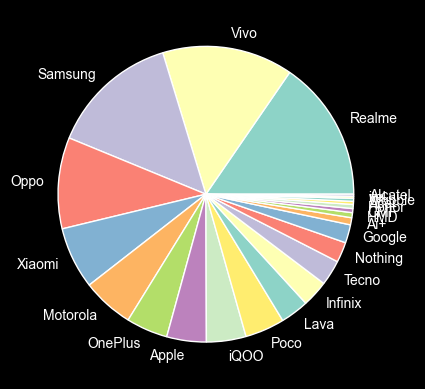

In [30]:
df['brand'].value_counts().plot(kind='pie')
plt.savefig('./plots/univariate_analysis/brand/pie_plot.png')

# price column univariate analysis
- budget phones are dominating (<100000)
- outlier exists `(mean is too high)`
- highly skewed ` (2.6280120605206196)`

In [33]:
df['price'].describe()

count       902.000000
mean      36032.215078
std       31932.852245
min        7499.000000
25%       16999.000000
50%       24999.000000
75%       39968.250000
max      222990.000000
Name: price, dtype: float64

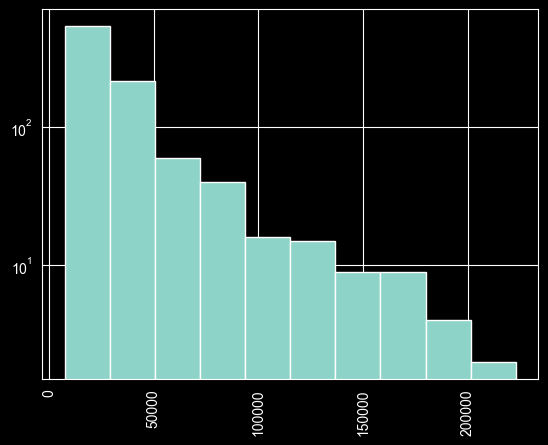

In [41]:
plt.hist(df['price'],bins=10,log=True)
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/price/hist_plot.png')

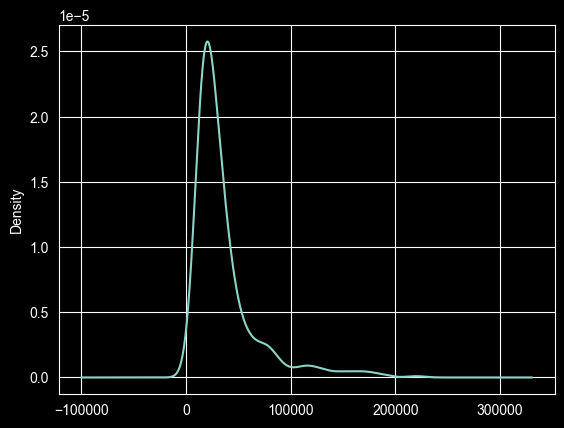

In [43]:
df['price'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/price/kde_plot.png')

In [166]:
df['price'].skew()

np.float64(2.6280120605206196)

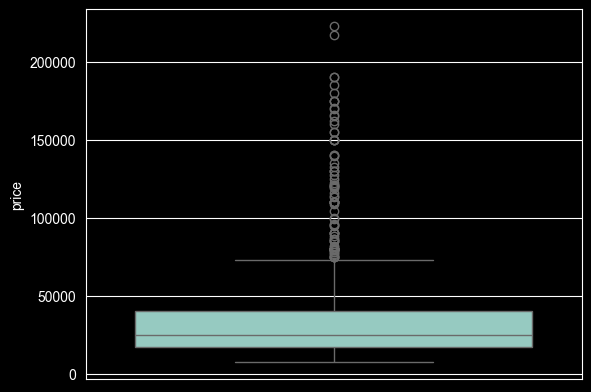

In [168]:
sns.boxplot(df['price'])
plt.savefig('./plots/univariate_analysis/price/box_plot.png')

In [170]:
df[df['price'] > 200000]

,Unnamed: 0,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
414,414,414,Apple,iPhone 17 Pro Max,222990,4.0,True,True,True,True,...,2868,iOS,False,NaN,48,18,3,1,Apple,A19 pro
506,506,506,Samsung,Galaxy Z Fold 7,216999,4.6,True,True,True,True,...,2184,Android,False,NaN,200,10,3,2,Snapdragon,8 elite for galaxy


In [171]:
df.drop(columns=['Unnamed: 0'],inplace=True)

# dual sim univariate analysis
- Except one phone all phones have dual sim

<Axes: xlabel='Dual Sim'>

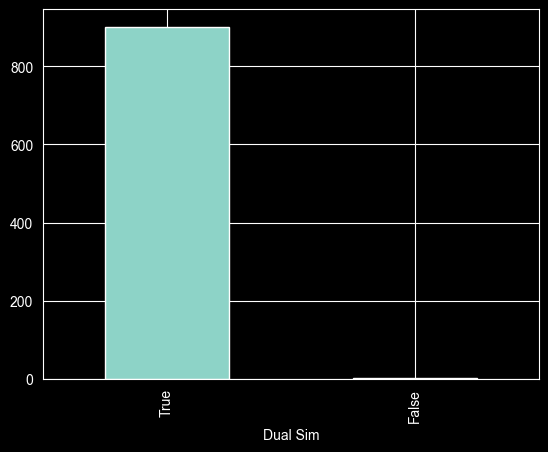

In [45]:
df['Dual Sim'].value_counts().plot(kind='bar')

## rating univariate analysis

In [176]:
df['rating'].isna().sum()

np.int64(0)

In [173]:
df['rating'].describe()

count    902.000000
mean       4.375831
std        0.231444
min        3.900000
25%        4.150000
50%        4.350000
75%        4.600000
max        4.750000
Name: rating, dtype: float64

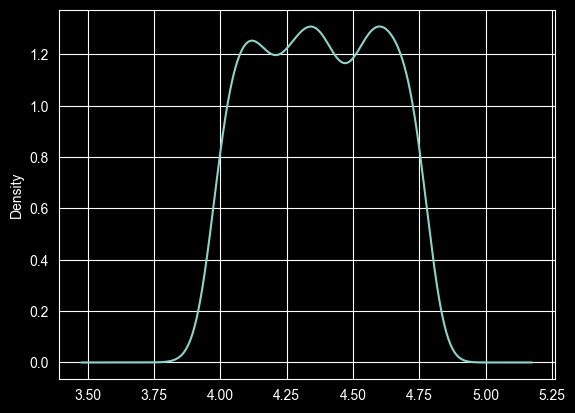

In [178]:
df['rating'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/rating/kde_plot.png')

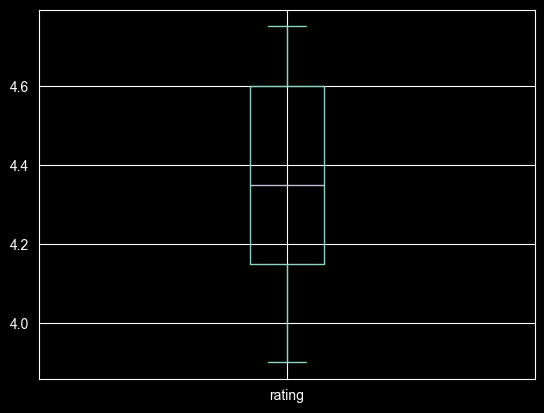

In [175]:
df['rating'].plot(kind='box')
plt.savefig('./plots/univariate_analysis/rating/box_plot.png')

# 3G univariate analysis
- all phones have 3G

# 4G univariate analysis
- all phones have 4G

# 5G univariate analysis
- all phones have 5G

# VoLTE univariate analysis
- Almost all phones have VoLTE except some Oppo, Realme and one Motorola phone

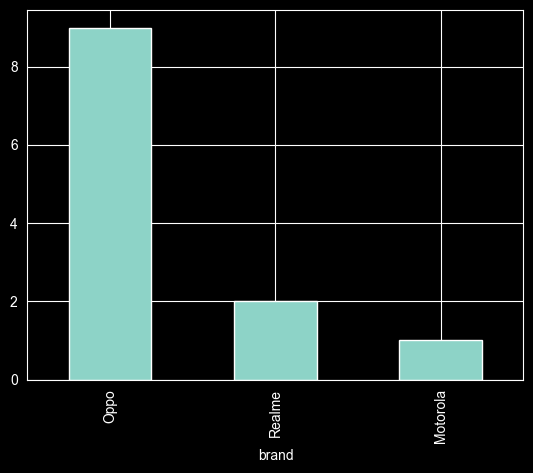

In [62]:
df[df['VoLTE'] == False]['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/VoLTE/bar_plot.png')

# Wi-Fi univariate analysis
- Every phone has Wi-Fi

<Axes: >

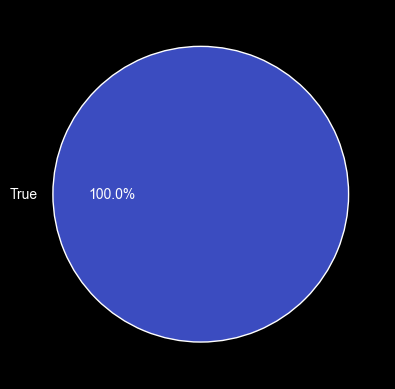

In [179]:
df['Wi-Fi'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='coolwarm')

# NFC univariate analysis
- Half of the phones have NFC

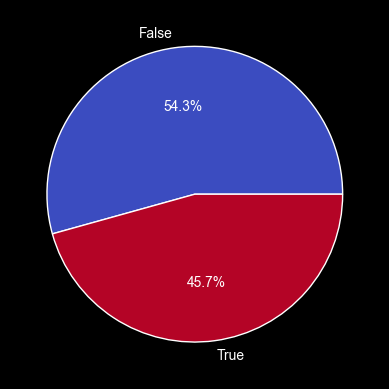

In [71]:
df['NFC'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/NFC/pie_plot.png')

# IR Blaster univariate analysis
- Mostly Chinese phones have ir blaster

In [181]:
df[df['IR Blaster']==True]['brand'].value_counts()

brand
Vivo       55
Xiaomi     51
Oppo       42
Realme     38
OnePlus    30
Poco       30
iQOO       24
Infinix    20
Tecno      19
Honor       2
Lava        1
itel        1
Name: count, dtype: int64

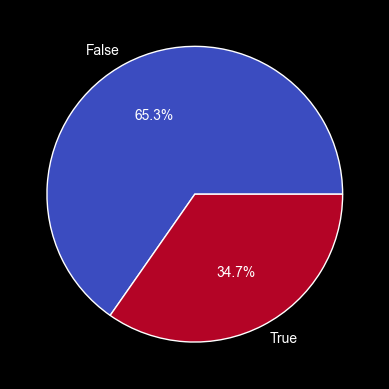

In [76]:
df['IR Blaster'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/IR_Blaster/pie_plot.png')

## processor_brand univariate analysis
- Most of the phones in the market have Dimensity, Snapdragon or Exynos processors

In [188]:
df[df['processor_brand'] == 'Other'].index

Index([83, 99, 111, 195, 203, 306, 333, 377, 407, 408, 556, 634, 656, 673, 761,
       770],
      dtype='int64')

In [190]:
df.loc[[83, 99, 111, 195, 203, 306, 333, 377, 407, 408, 556, 634, 656, 673, 761,
       770],'processor_brand'] = 'Google'

In [191]:
df['processor_brand'].value_counts()

processor_brand
Dimensity     449
Snapdragon    320
Exynos         57
Apple          39
Unisoc         19
Google         18
Name: count, dtype: int64

<Axes: >

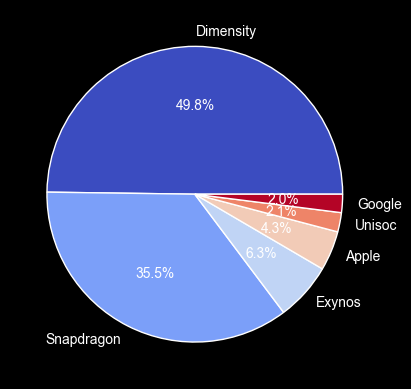

In [193]:
df['processor_brand'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')

# processor_core univariate analysis
- 93.8% of the phones have 8 core processor

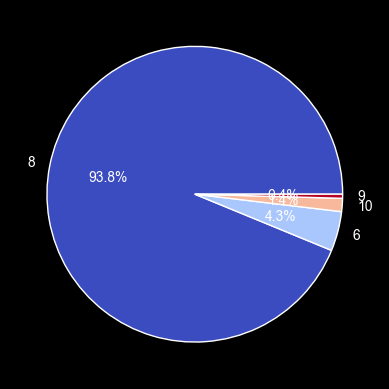

In [79]:
df['processor_core'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/processor_core/pie_plot.png')

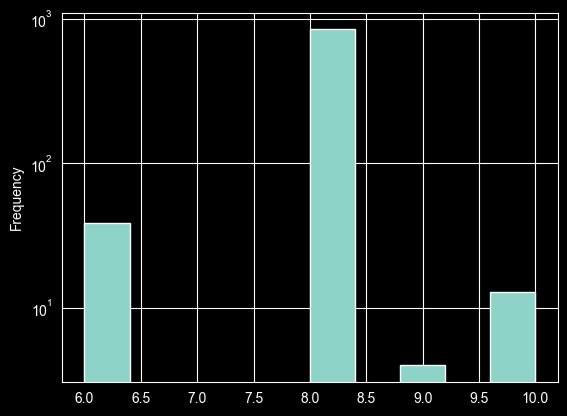

In [82]:
df['processor_core'].plot(kind='hist',log=True)
plt.savefig('./plots/univariate_analysis/processor_core/hist_plot.png')

# processor_speed_in_GHz univariate analysis
- majority of the processor has speed between 2.25 - 2.5 GHz
- weird anomaly between 3-3.5 GHz speed
- there are 53 outliers `(speed > 3.9 GHz)`

In [84]:
df['processor_speed_in_GHz'].describe()

count    865.000000
mean       2.750486
std        0.563318
min        2.000000
25%        2.400000
50%        2.500000
75%        3.000000
max        4.740000
Name: processor_speed_in_GHz, dtype: float64

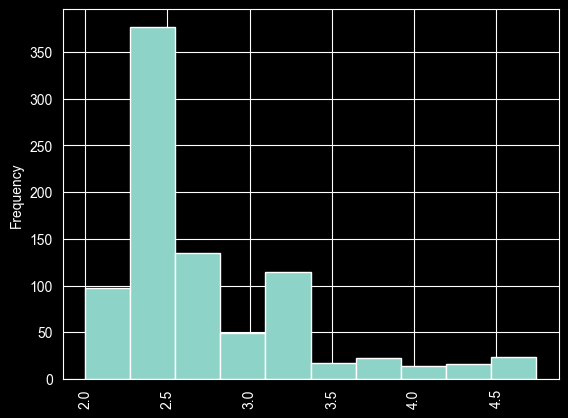

In [90]:
df['processor_speed_in_GHz'].plot(kind='hist')
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/hist_plot.png')

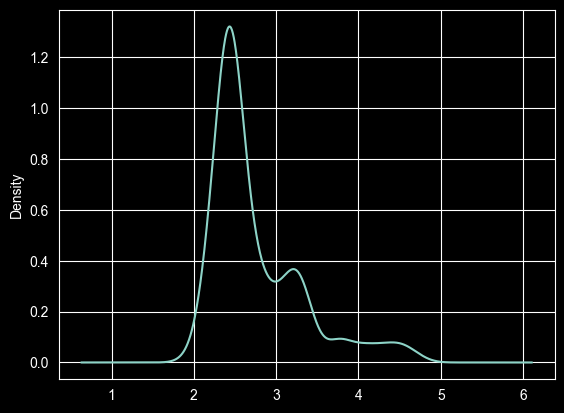

In [141]:
df['processor_speed_in_GHz'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/kde_plot.png')

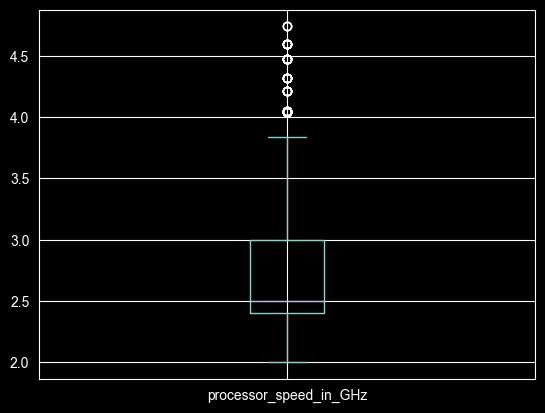

In [93]:
df['processor_speed_in_GHz'].plot(kind='box')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/box_plot.png')

### Fixing some missing and misplaced values in the os and battery_capacity columns

In [137]:
df[(df['processor_speed_in_GHz'] >= 3.0) & (df['processor_speed_in_GHz'] <= 3.5) ].groupby(['brand','os'])

KeyError: ('Vivo', 'iOS')

In [136]:
df.loc[[713],'os'] = "Android"

In [139]:
df.to_csv('../filled_osnNA_cleaned_5G_smartphone.csv')

In [195]:
df = pd.read_csv('./assets/final.csv')

In [162]:
df[df['battery_capacity'].isna()]

,Unnamed: 0,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
678,678,678,Apple,iPhone 12 Pro Max,119900,4.6,True,True,True,True,...,2778,iOS,False,NaN,12,12,3,1,Apple,A14
731,731,731,Apple,iPhone 12 Pro,109900,4.0,True,True,True,True,...,2532,iOS,False,NaN,12,12,3,1,Apple,A14


In [156]:
df.loc[[678,731],'battery_capacity']

678   NaN
731   NaN
Name: battery_capacity, dtype: float64

In [194]:
df.to_csv('./assets/final.csv',index=False)

In [196]:
df

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,3120,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
1,1,OnePlus,Nord 6,38999,4.60,True,True,True,True,True,...,2772,Android,False,NaN,50,32,2,1,Snapdragon,8s gen4
2,2,Samsung,Galaxy S25 FE,44999,4.70,True,True,True,True,True,...,2340,Android,False,NaN,50,12,3,1,Exynos,2400
3,3,Vivo,T5x 5G,18999,4.10,True,True,True,True,True,...,2344,Android,False,NaN,50,32,2,1,Dimensity,7400 turbo
4,4,Infinix,Note 60 Pro 5G,31999,4.75,True,True,True,True,True,...,2644,Android,True,1024.0,50,13,2,1,Snapdragon,7s gen4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,897,Tecno,Spark 10 5G,13800,4.55,True,True,True,True,True,...,1612,Android,True,1024.0,50,8,2,1,Dimensity,6020
898,898,Xiaomi,Redmi Note 12,18499,4.20,True,True,True,True,True,...,2400,Android,True,1024.0,48,13,3,1,Snapdragon,4 gen 1
899,899,Realme,11,18999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,108,16,2,1,Dimensity,6100 plus
900,900,Motorola,Razr 40 Ultra,59990,4.20,True,True,True,True,True,...,2640,Android,False,NaN,13,32,2,1,Snapdragon,8+ gen1


### Ram univariate analysis
- majority of the phones have 8 gb ram

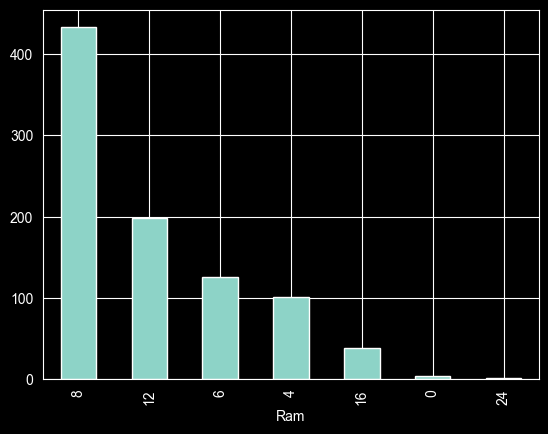

In [199]:
df['Ram'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/Ram/bar_plot.png')

### storage univariate analysis
- most phones have 128GB or 256GB storage

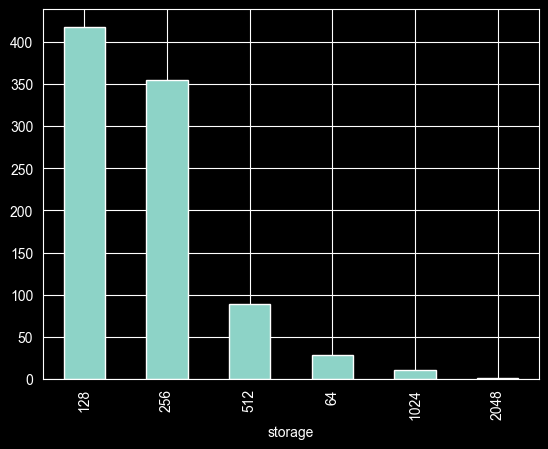

In [212]:
df['storage'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/storage/bar_plot.png')

## battery_capacity univariate analysis
- most phones have around 5000mAh battery capacity
- Outlier exists! 9 chinese phone with exceptionally high battery capacity ` > 8000 mAh`

In [213]:
df['battery_capacity'].describe()

count      900.000000
mean      5598.230000
std        984.900844
min       3149.000000
25%       5000.000000
50%       5320.000000
75%       6200.000000
max      10001.000000
Name: battery_capacity, dtype: float64

<Axes: ylabel='Density'>

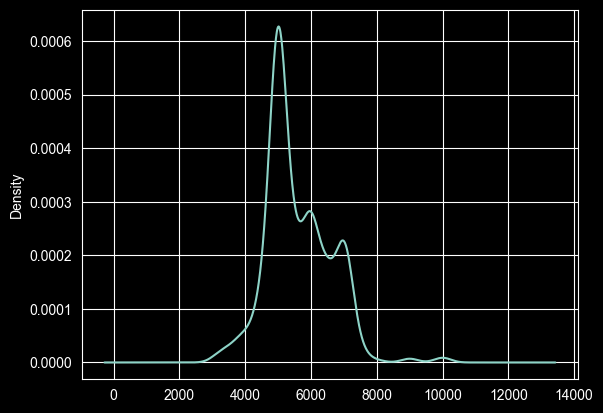

In [214]:
df['battery_capacity'].plot(kind='kde')

<Axes: ylabel='Frequency'>

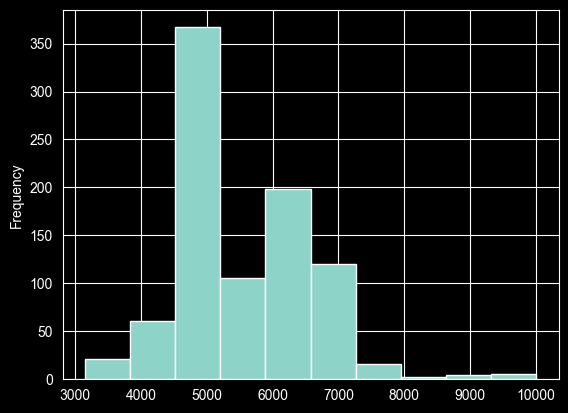

In [215]:
df['battery_capacity'].plot(kind='hist')

<Axes: >

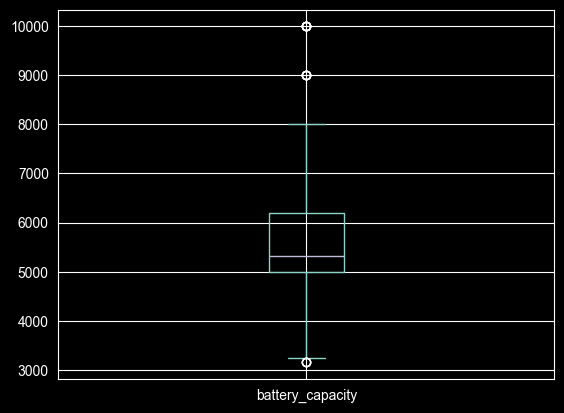

In [216]:
df['battery_capacity'].plot(kind='box')

In [220]:
df[df['battery_capacity'] > 8000][['brand','model','battery_capacity']]

,brand,model,battery_capacity
1,OnePlus,Nord 6,9000.0
8,OnePlus,Nord 6 5G,9000.0
19,Realme,P4 Power 5G,10001.0
120,Realme,Narzo Power 5G,10001.0
124,Poco,X8 Pro Max,9000.0
166,Realme,P4 Power 5G,10001.0
206,Realme,Narzo Power 5G,10001.0
294,Poco,X8 Pro Max 5G,9000.0
342,Realme,P4 Power 5G,10001.0


## is_fast_charging
- Except 1 every phone has fast charging ` index 539`

In [221]:
df['is_fast_charging'].value_counts()

is_fast_charging
True     901
False      1
Name: count, dtype: int64

In [222]:
df[df['is_fast_charging'] == False]

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
539,539,Lava,Blaze AMOLED 2,14999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,50,8,2,1,Dimensity,7060


## fast_charging_capacity
- majority of the phones have fast_charging_capacity around either 50W or 80W

In [223]:
df['fast_charging_capacity'].describe()

count    850.000000
mean      54.335294
std       28.467688
min        0.000000
25%       33.000000
50%       45.000000
75%       80.000000
max      125.000000
Name: fast_charging_capacity, dtype: float64

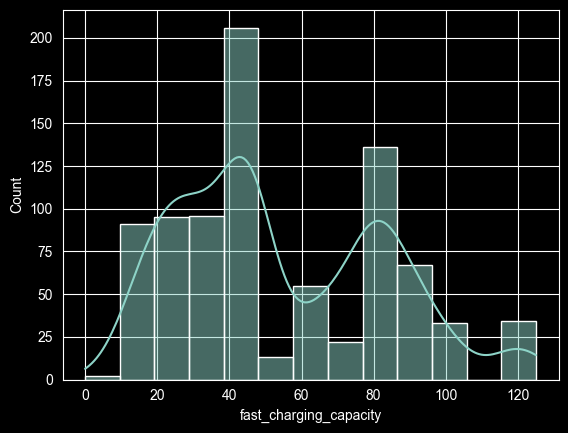

In [227]:
sns.histplot(data=df,x='fast_charging_capacity',kde=True)
plt.savefig('./plots/univariate_analysis/fast_charging_capacity/hist_plot.png')

<Axes: >

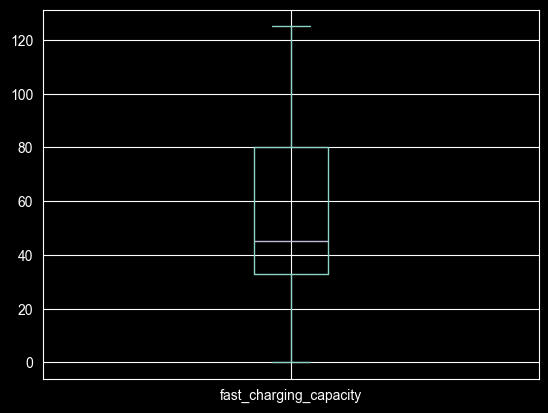

In [228]:
df['fast_charging_capacity'].plot(kind='box')

## display_refresh_rate
- Majority phones have 120 Hz refresh rate

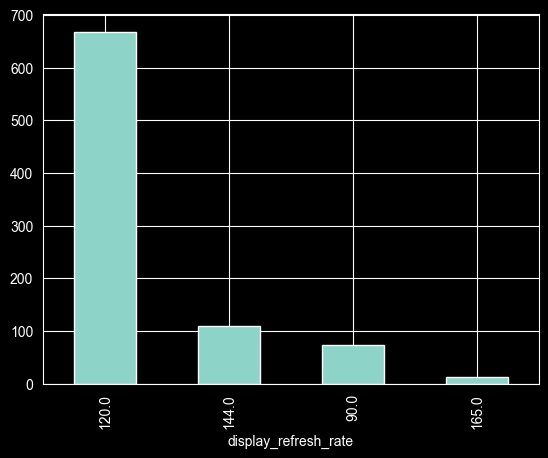

In [231]:
df['display_refresh_rate'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/display_refresh_rate/bar_plot.png')

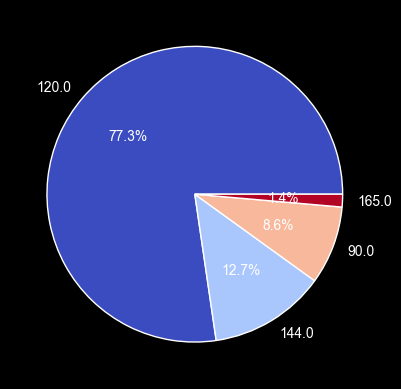

In [237]:
df['display_refresh_rate'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/display_refresh_rate/pie_plot.png')

## display_size

In [233]:
df['display_size'].describe()

count    902.000000
mean       6.702151
std        0.205323
min        6.100000
25%        6.670000
50%        6.710000
75%        6.780000
max        8.030000
Name: display_size, dtype: float64

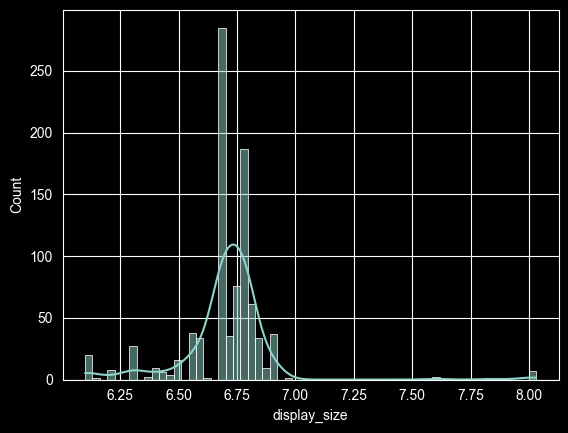

In [235]:
sns.histplot(data=df,x='display_size',kde=True)
plt.savefig('./plots/univariate_analysis/display_size/hist_plot.png')

## pixel_width
- outlier exists! Some phones are flip phones or foldable phones and some phones have pixel width and height swapped
- foldable phones index: [437, 506, 656, 669, 688, 713, 714, 751, 761, 843]
- swapped values index: [7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826]

In [239]:
df['pixel_width'].describe()

count     902.000000
mean     1105.240576
std       279.176605
min       720.000000
25%      1080.000000
50%      1080.000000
75%      1252.000000
max      2790.000000
Name: pixel_width, dtype: float64

<Axes: xlabel='pixel_width', ylabel='Count'>

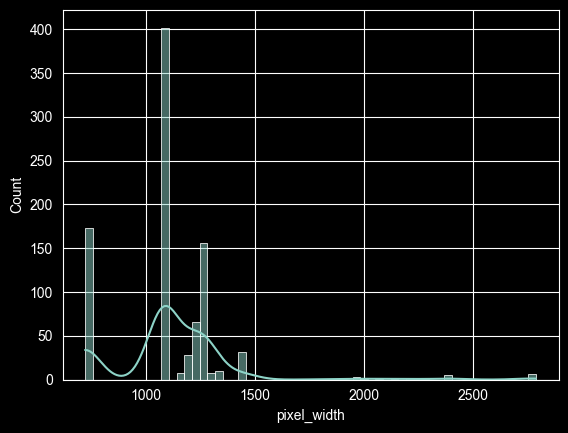

In [242]:
sns.histplot(data=df,x='pixel_width',kde=True)

<Axes: >

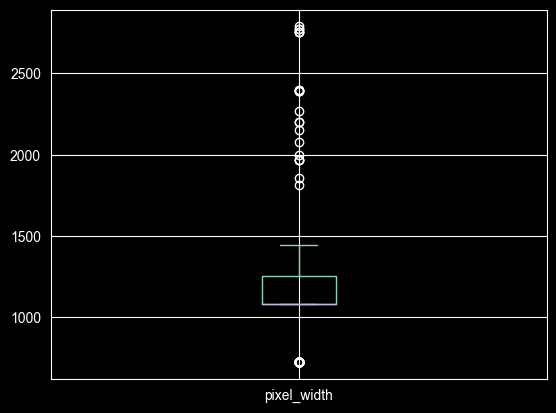

In [241]:
df['pixel_width'].plot(kind='box')

### fixing swapped pixels of phones

In [275]:
df[df['pixel_width'] > 1500]['model'][df[df['pixel_width'] > 1500]['model'].apply(lambda x: True if "Fold" not in str(x) else False )].index

Index([7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826], dtype='int64')

In [268]:
df[df['pixel_width'] > 1500]['model'][df[df['pixel_width'] > 1500]['model'].str.contains('Fold')].index

Index([437, 506, 656, 669, 688, 713, 714, 751, 761, 843], dtype='int64')

In [289]:
x = df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width']].values
y = df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_height']].values

In [290]:
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width']] = y
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_height']] = x

In [294]:
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width','pixel_height']]

,pixel_width,pixel_height
7,1272,2772
14,1080,2392
44,1272,2772
72,1268,2756
108,1080,2392
130,1188,2790
205,1080,2392
343,1268,2756
398,1268,2756
757,2440,2268


In [292]:
df.to_csv('./assets/final.csv',index=False)

In [293]:
df = pd.read_csv('./assets/final.csv')

### creating display_ppi feature

In [307]:
def calculate_ppi(row):
    width = row['pixel_width']
    height = row['pixel_height']
    diagonal_inches = row['display_size']
    pixel_diagonal = np.sqrt(width**2 + height**2)
    ppi = pixel_diagonal / diagonal_inches
    return ppi

df['display_ppi'] = calculate_ppi(df[['pixel_width','pixel_height','display_size']])

In [322]:
df.to_csv('./assets/final.csv',index=False)

In [323]:
df = pd.read_csv('./assets/final.csv')

In [317]:
x = df.pop('display_ppi')

In [319]:
df.insert(26,"display_ppi",x)

## os
- majority phones have Android os

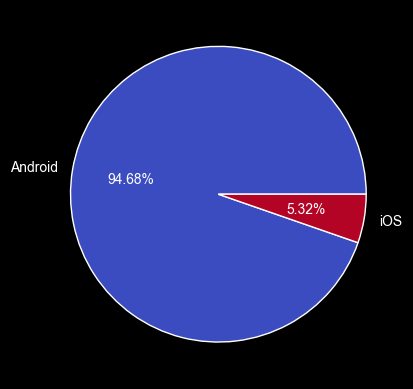

In [331]:
df['os'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/os/pie_plot.png')

## is_memory_card_supported

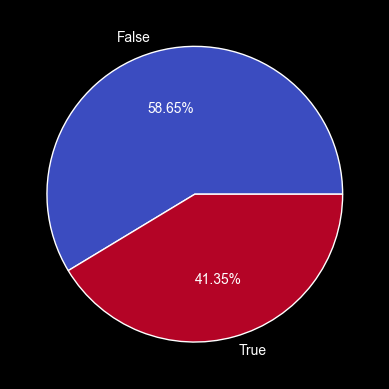

In [335]:
df['is_memory_card_supported'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/is_memory_card_supported/pie_plot.png')

## max_card_gb

In [339]:
df['max_card_gb'].describe()

count     292.000000
mean     1372.054795
std       499.361404
min       256.000000
25%      1024.000000
50%      1024.000000
75%      2048.000000
max      2048.000000
Name: max_card_gb, dtype: float64

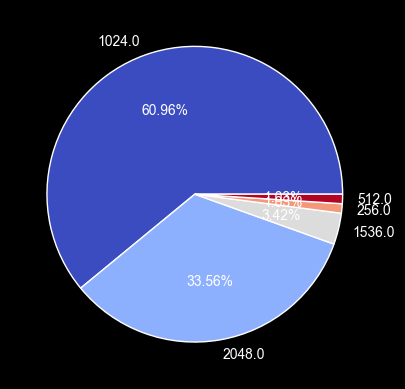

In [368]:
df['max_card_gb'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/max_card_gb/pie_plot.png')

## primary_rear_mp
- mostly chinese phones have higher megapixel camera
- expensive phones with price > 100000 and >100MP camera are mostly `Samsung`

In [341]:
df['primary_rear_mp'].value_counts()

primary_rear_mp
50     647
48      54
200     51
64      51
108     37
13      29
32      20
12      10
8        1
2        1
180      1
Name: count, dtype: int64

In [346]:
df[df['primary_rear_mp'] > 100][df[df['primary_rear_mp'] > 100]['price'] >100000]

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,display_ppi,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
18,18,Samsung,Galaxy S26 Ultra 5G,120850,4.45,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
82,82,Samsung,Galaxy S26 Ultra,119990,4.60,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
122,122,Vivo,X300 Pro 5G,109999,4.35,True,True,True,True,True,...,452.867214,Android,False,NaN,200,50,3,1,Dimensity,9500
146,146,Oppo,Find X9 Pro 5G,109999,4.55,True,True,True,True,True,...,449.839644,Android,False,NaN,200,50,3,1,Dimensity,9500
159,159,Samsung,Galaxy S24 Ultra,119999,4.35,True,True,True,True,True,...,505.334861,Android,False,NaN,200,12,4,1,Snapdragon,8 gen3
192,192,Xiaomi,17 Ultra,139999,4.15,True,True,True,True,True,...,416.062296,Android,False,NaN,200,50,3,1,Snapdragon,8 elite gen 5
207,207,Samsung,Galaxy S26 Ultra,189999,4.10,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
270,270,Samsung,Galaxy S25 Ultra,120999,4.65,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
437,437,Samsung,Galaxy Z Fold 7,174999,4.40,True,True,True,True,True,...,367.484694,Android,False,NaN,200,10,3,2,Snapdragon,8 elite for galaxy


## num_rear_camera
- majority phones which have 2 rear cameras are chinese

In [348]:
df['num_rear_cameras'].value_counts()

num_rear_cameras
2    476
3    356
1     52
4     18
Name: count, dtype: int64

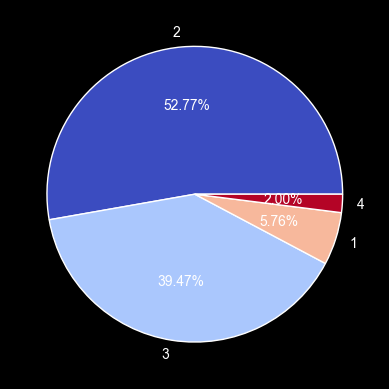

In [369]:
df['num_rear_cameras'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/num_rear_cameras/pie_plot.png')

In [352]:
df[df['num_rear_cameras'] ==2][['brand']].value_counts()

brand   
Realme      97
Vivo        82
Oppo        47
Motorola    33
iQOO        33
Xiaomi      28
Poco        27
Samsung     20
Lava        18
OnePlus     17
Infinix     17
Tecno       16
Apple       14
Google       8
Ai+          5
Nothing      5
HMD          3
CMF          2
itel         2
Honor        1
Alcatel      1
Name: count, dtype: int64

## primary_front_mp
- mostly chines phones have higher MP rear camera

In [354]:
df['primary_front_mp'].value_counts()

primary_front_mp
32    178
8     158
16    148
50    134
13     80
12     70
5      65
20     36
10     16
18     12
42      4
44      1
Name: count, dtype: int64

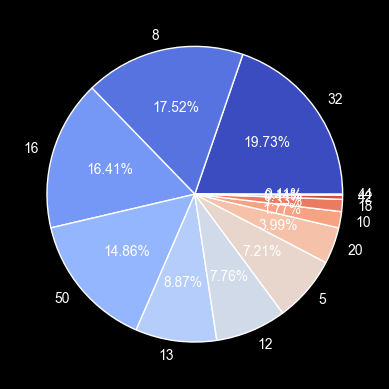

In [370]:
df['primary_front_mp'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/primary_front_mp/pie_plot.png')

In [356]:
df[df['primary_front_mp'] ==32]['brand'].value_counts()

brand
Vivo        33
Realme      28
Motorola    26
iQOO        21
Oppo        20
OnePlus     15
Nothing     11
Xiaomi       8
Samsung      8
Infinix      4
Tecno        2
Ai+          1
Alcatel      1
Name: count, dtype: int64

## num_front_cameras
- majority of the phones have 1 front camera
- except few high-end phones all phones with 2 front cameras are flagship phones

In [357]:
df['num_front_cameras'].value_counts()

num_front_cameras
1    887
2     15
Name: count, dtype: int64

In [361]:
df[df['num_front_cameras'] == 2][['price']].describe()

,price
count,15.000000
mean,121891.133333
std,58252.821781
min,29990.000000
25%,72499.000000
50%,139499.000000
75%,157498.500000
max,216999.000000


## processor_brand
- majority phones have either Dimenisity or Snapdragon processor
- Google and Apple have their own in-house chips
- Realme, Vivo and Oppo are the three companies that uses more Dimensity processors than others
- Almost every company equally uses Snapdragon processor

In [362]:
df['processor_brand'].value_counts()

processor_brand
Dimensity     449
Snapdragon    320
Exynos         57
Apple          39
Unisoc         19
Google         18
Name: count, dtype: int64

In [364]:
df[df['processor_brand'] == 'Dimensity']['price'].describe()

count       449.000000
mean      24755.376392
std       15286.929023
min        9490.000000
25%       15499.000000
50%       19999.000000
75%       28494.000000
max      109999.000000
Name: price, dtype: float64

In [365]:
df[df['processor_brand'] == 'Dimensity']['brand'].value_counts()

brand
Realme      93
Vivo        80
Oppo        73
Samsung     30
Tecno       25
Infinix     24
Lava        21
Xiaomi      20
Motorola    18
iQOO        18
Poco        16
Nothing      7
OnePlus      6
CMF          4
Ai+          3
Acer         3
Wobble       3
itel         2
Alcatel      2
Honor        1
Name: count, dtype: int64

In [366]:
df[df['processor_brand'] == 'Snapdragon']['price'].describe()

count       320.000000
mean      41020.171875
std       32342.213362
min        9499.000000
25%       21999.000000
50%       30999.000000
75%       45999.000000
max      216999.000000
Name: price, dtype: float64

In [367]:
df[df['processor_brand'] == 'Snapdragon']['brand'].value_counts()

brand
Vivo        49
Realme      46
Samsung     40
Xiaomi      38
OnePlus     35
Motorola    31
iQOO        21
Poco        21
Oppo        17
Nothing     13
Honor        3
Infinix      2
HMD          2
Lava         2
Name: count, dtype: int64

In [371]:
df.to_csv('./assets/final.csv',index=False)

In [6]:
df= pd.read_csv('./assets/imputed_fixed.csv')

In [376]:
df.to_excel('./assets/cleaned_5G_smartphone.xlsx',index=False)

# Bivariate analysis

## price / brand

In [396]:
x = (df['brand'].value_counts() > 10)[df['brand'].value_counts() > 10].index

In [398]:
temp_df = df[df['brand'].isin(x)]

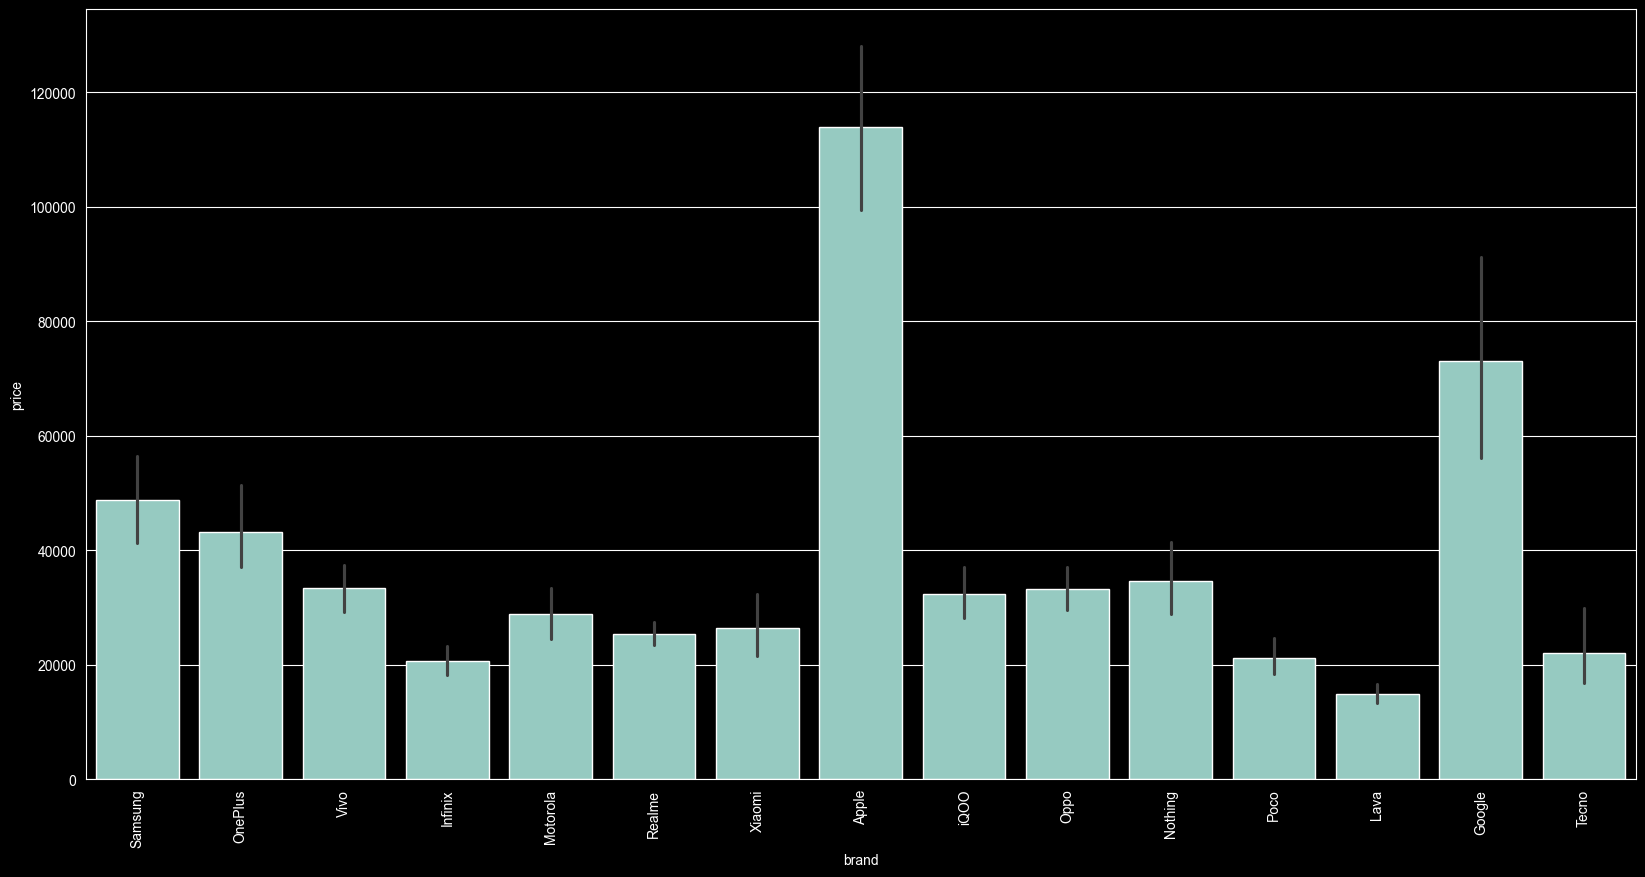

In [408]:
plt.figure(figsize=(20,10))
sns.barplot(data=temp_df,x='brand',y='price',estimator='mean')
plt.xticks(rotation=90)
plt.savefig('./plots/bivariate_analysis/price-brand/bar_plot.png')
plt.show()

## price / rating

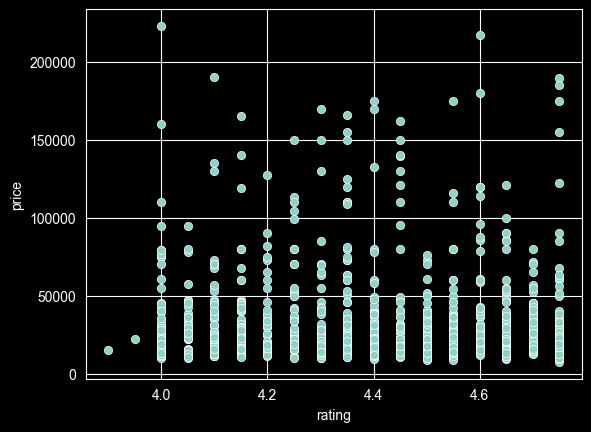

In [410]:
sns.scatterplot(data=df,x='rating',y='price')
plt.savefig('./plots/bivariate_analysis/price-rating/scatter_plot.png')

## price - NFC

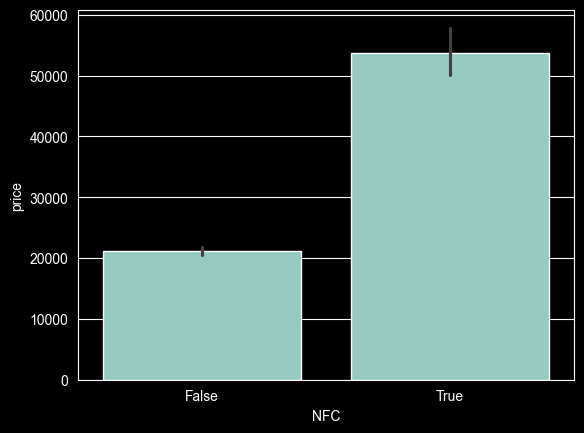

In [414]:
sns.barplot(data=df,x='NFC',y='price')
plt.savefig('./plots/bivariate_analysis/price-NFC/bar_plot.png')

In [22]:
df[df['NFC'] == True]['brand'].value_counts()

brand
Samsung     95
Vivo        40
Apple       39
OnePlus     34
Motorola    30
Oppo        30
Realme      28
Nothing     20
Google      18
Xiaomi      16
Infinix     15
Tecno       14
iQOO        13
Poco        12
Honor        3
HMD          2
Alcatel      2
Ai+          1
Name: count, dtype: int64

In [26]:
df[df['NFC'] == True]['price'].describe()

count       412.000000
mean      53744.900485
std       39624.140309
min        9490.000000
25%       26999.000000
50%       39999.000000
75%       69999.000000
max      222990.000000
Name: price, dtype: float64

In [28]:
iqr = (70000-27000)*1.5
df[(df['NFC'] == True) & (df['price'] >= 70000+iqr)]['brand'].value_counts()

brand
Apple      13
Samsung     8
Xiaomi      1
Google      1
Vivo        1
OnePlus     1
Name: count, dtype: int64

<Axes: >

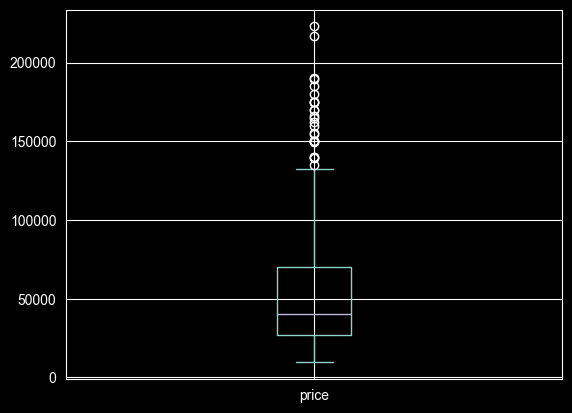

In [25]:
df[df['NFC'] == True]['price'].plot(kind='box')

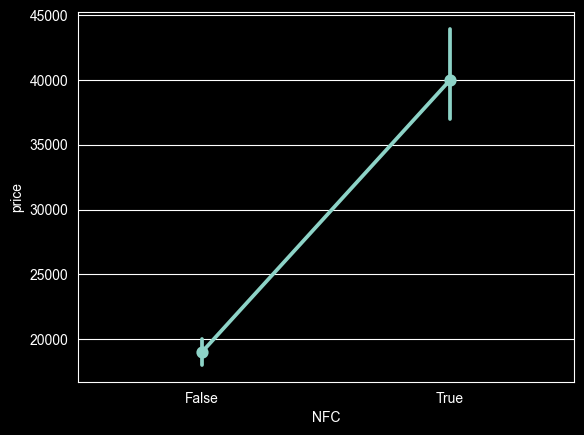

In [415]:
sns.pointplot(data=df,x='NFC',y='price',estimator='median')
plt.savefig('./plots/bivariate_analysis/price-NFC/pointplot_plot.png')

## price - IR Blaster

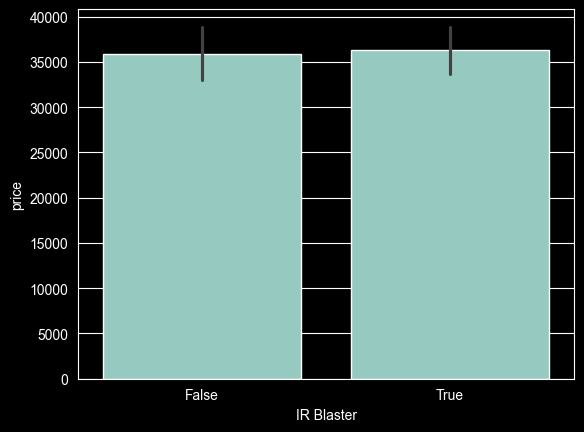

In [417]:
sns.barplot(data=df,x='IR Blaster',y='price')
plt.savefig('./plots/bivariate_analysis/price-IR_Blaster/bar_plot.png')

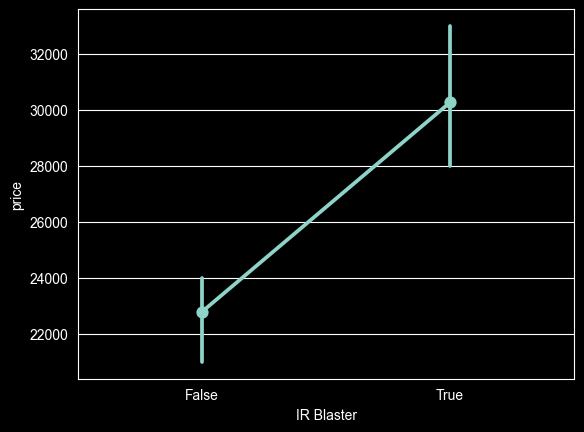

In [421]:
sns.pointplot(data=df,x='IR Blaster',y='price',estimator='median')
plt.savefig('./plots/bivariate_analysis/price-IR_Blaster/pointplot_plot.png')

## price - processor_brand

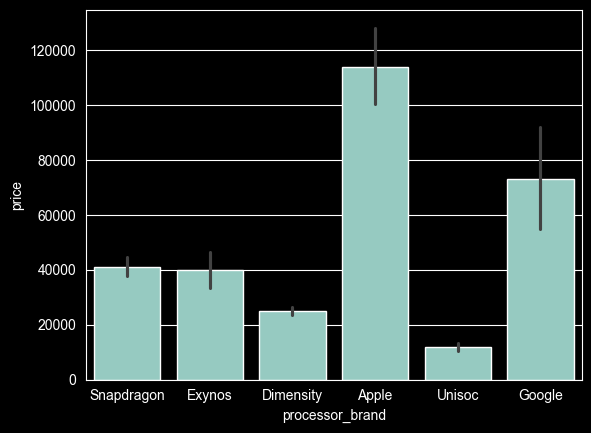

In [424]:
sns.barplot(data=temp_df,x='processor_brand',y='price')
plt.savefig('./plots/bivariate_analysis/price-processor_brand/bar_plot.png')

## price - processor_core
- apples chipset has hexacore

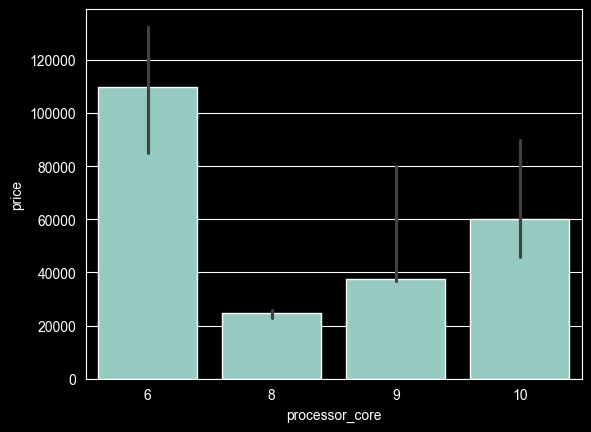

In [428]:
sns.barplot(data=temp_df,x='processor_core',y='price',estimator='median')
plt.savefig('./plots/bivariate_analysis/price-processor_core/bar_plot.png')

In [426]:
pd.crosstab(df['processor_core'],df['os'])

os,Android,iOS
processor_core,,
6,0,39
8,837,9
9,4,0
10,13,0


## price - processor_speed_in_GHz

<Axes: xlabel='processor_speed_in_GHz', ylabel='price'>

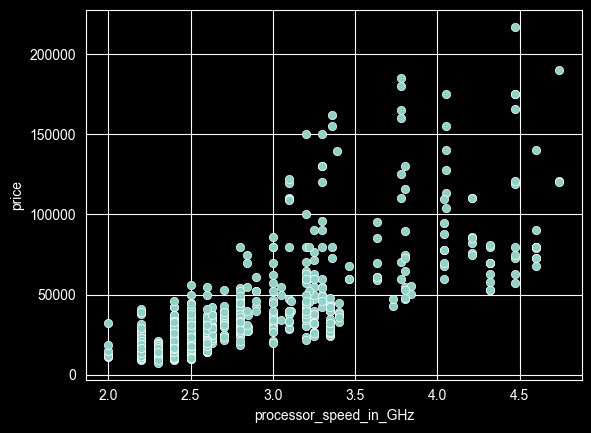

In [429]:
sns.scatterplot(data=df,x='processor_speed_in_GHz',y='price')

In [469]:
temp = df.select_dtypes(include='number').corr()['price']
temp = temp.reset_index()

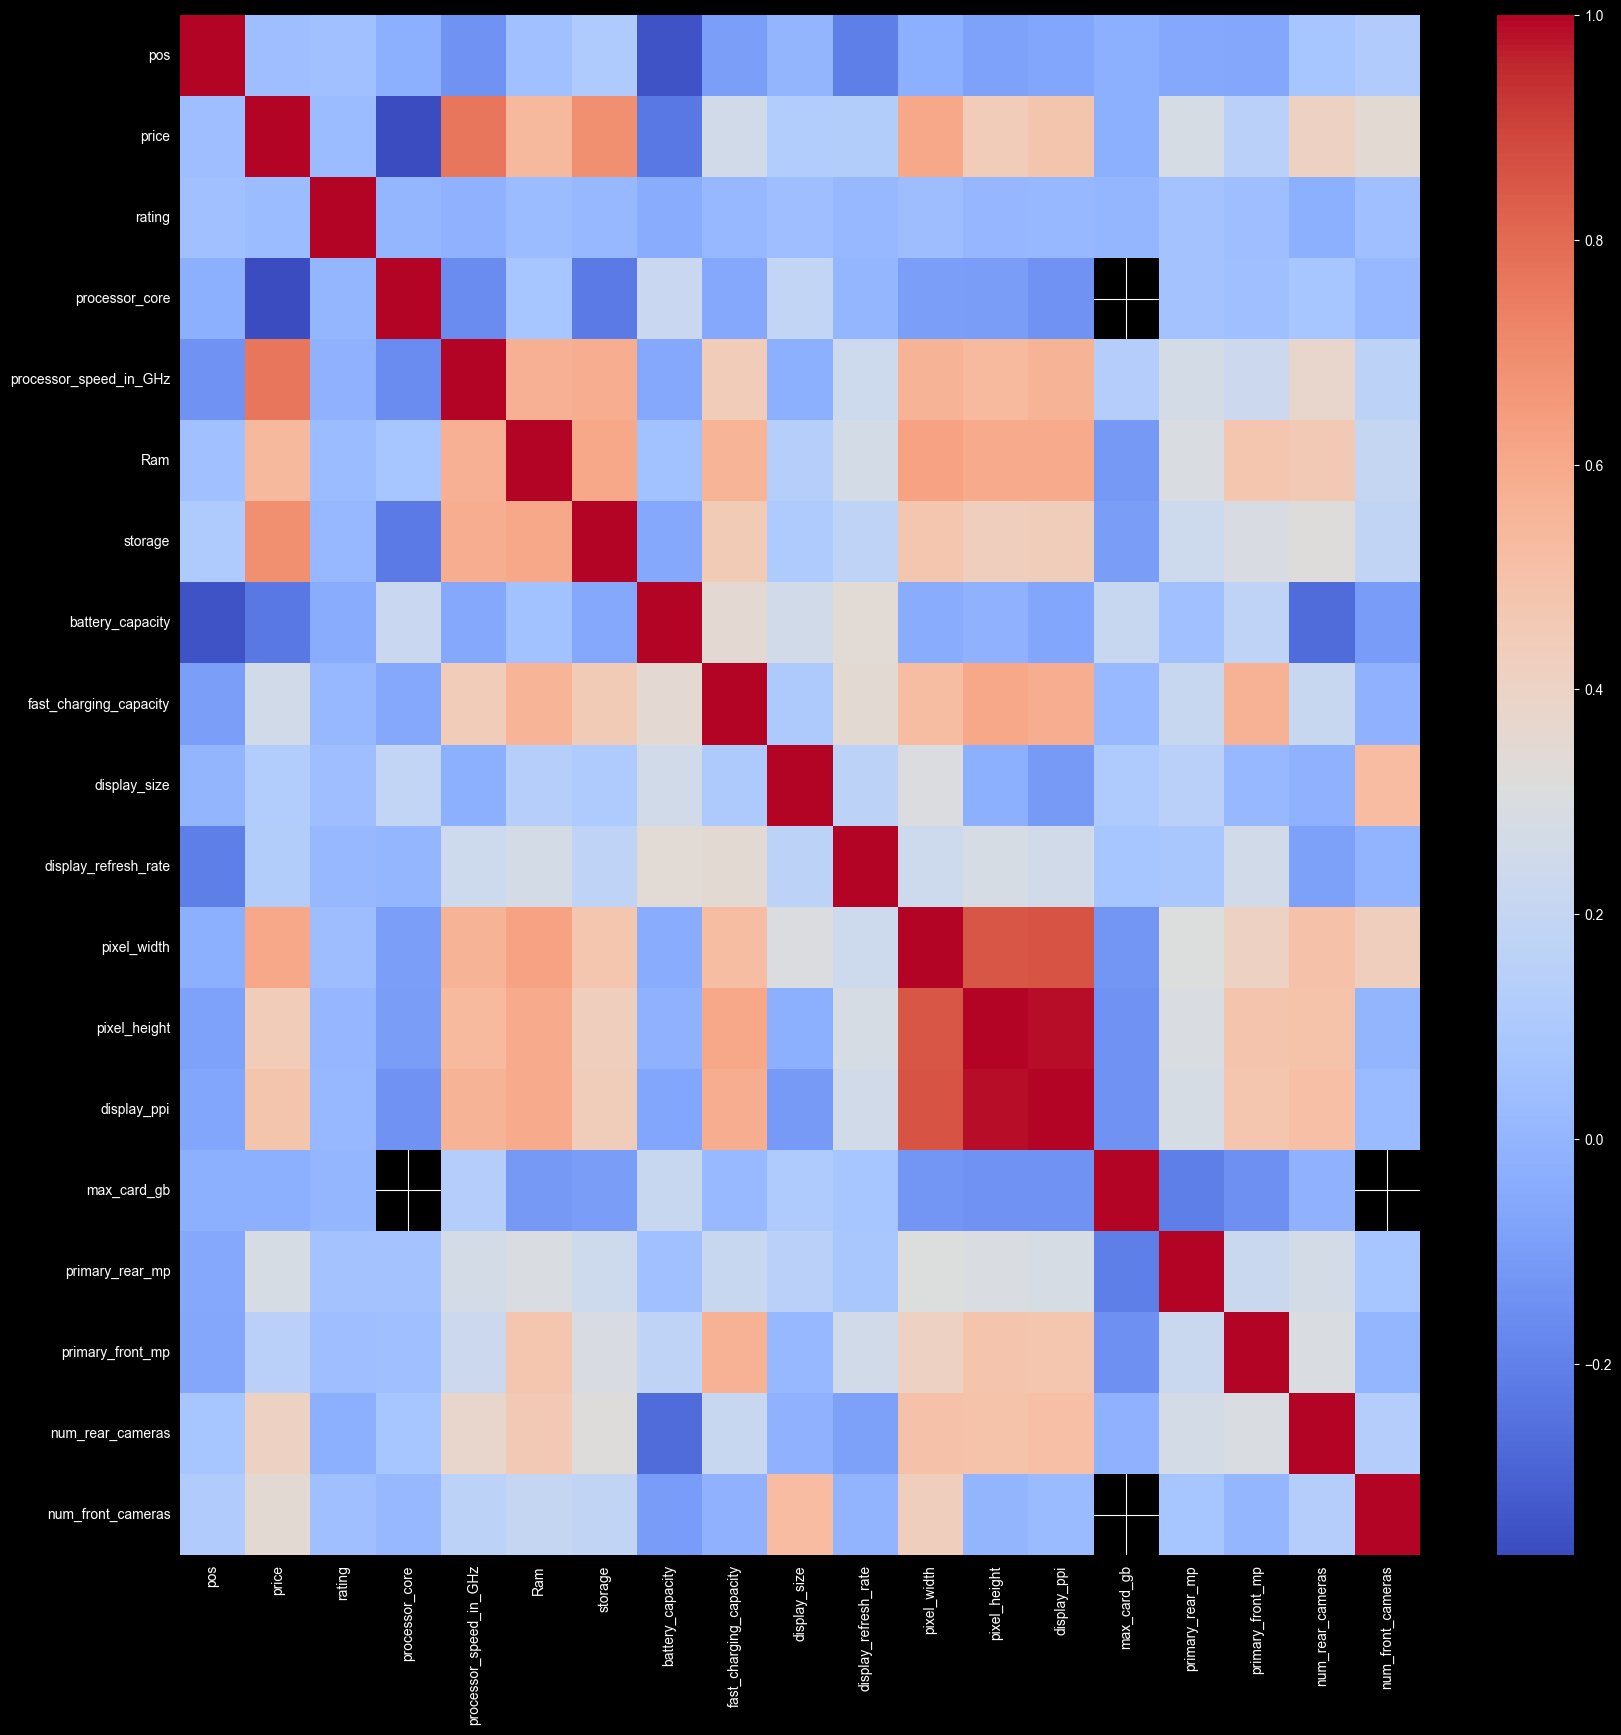

In [444]:
plt.figure(figsize=(20,20))
x = df.select_dtypes(include='number').corr()
sns.heatmap(data=x,cmap='coolwarm')
plt.savefig('./plots/bivariate_analysis/price-corr/heatmap.png')

In [436]:
df.isnull().sum()

pos                           0
brand                         0
model                         0
price                         0
rating                        0
Dual Sim                      0
3G                            0
4G                            0
5G                            0
VoLTE                         0
Vo5G                          0
Wi-Fi                         0
NFC                           0
IR Blaster                    0
processor_core                0
processor_speed_in_GHz       37
Ram                           0
storage                       0
battery_capacity              2
is_fast_charging              0
fast_charging_capacity       52
display_size                  0
display_refresh_rate         38
camera_notch_type             8
pixel_width                   0
pixel_height                  0
display_ppi                   0
os                            0
is_memory_card_supported      0
max_card_gb                 610
primary_rear_mp               0
primary_

In [500]:
x = df.select_dtypes(include='number')
x.corr()['processor_speed_in_GHz']

pos                      -0.139739
price                     0.768641
rating                   -0.014691
processor_core           -0.162468
processor_speed_in_GHz    1.000000
Ram                       0.573454
storage                   0.585433
battery_capacity         -0.056884
fast_charging_capacity    0.443612
display_size             -0.023101
display_refresh_rate      0.237632
pixel_width               0.566067
pixel_height              0.531724
display_ppi               0.562296
max_card_gb               0.131079
primary_rear_mp           0.263488
primary_front_mp          0.226069
num_rear_cameras          0.378098
num_front_cameras         0.160179
Name: processor_speed_in_GHz, dtype: float64

## knn imputation

In [501]:
x_df = x.drop(columns='price')

In [502]:
x_df.head()

,pos,rating,processor_core,processor_speed_in_GHz,Ram,storage,battery_capacity,fast_charging_capacity,display_size,display_refresh_rate,pixel_width,pixel_height,display_ppi,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras
0,0,4.15,8,4.47,12,256,5000.0,45.0,6.90,120.0,1440,3120,498.011167,NaN,200,12,4,1
1,1,4.60,8,3.20,8,256,9000.0,80.0,6.78,165.0,1272,2772,449.839644,NaN,50,32,2,1
2,2,4.70,10,3.20,8,128,4900.0,45.0,6.70,120.0,1080,2340,384.657879,NaN,50,12,3,1
3,3,4.10,8,2.60,6,128,7200.0,44.0,6.76,120.0,1080,2344,381.781091,NaN,50,32,2,1
4,4,4.75,8,2.40,8,128,6500.0,90.0,6.78,144.0,1208,2644,428.744597,1024.0,50,13,2,1


In [498]:
from sklearn.impute import KNNImputer, SimpleImputer


In [450]:
imputer = SimpleImputer(strategy='median')

In [503]:
x_df_values = imputer.fit_transform(x_df)

In [504]:
x_df = pd.DataFrame(x_df_values, columns=x_df.columns)

In [505]:
x_df['price'] = df['price']

In [506]:
cols = x_df.columns

In [508]:
temp2 = x_df.corr()['price']
temp2 =temp2.reset_index()

In [509]:
temp.merge(temp2,on='index')

,index,price_x,price_y
0,pos,0.041813,0.041813
1,price,1.000000,1.000000
2,rating,0.029573,0.029573
3,processor_core,-0.370266,-0.370266
4,processor_speed_in_GHz,0.768641,0.765311
5,Ram,0.535237,0.535237
6,storage,0.692414,0.692414
7,battery_capacity,-0.228331,-0.228547
8,fast_charging_capacity,0.255827,0.165903
9,display_size,0.121044,0.121044


In [510]:
final_df = df.copy()

In [511]:
x_df = x_df.astype({col: 'float64' for col in cols})

In [512]:
final_df = final_df.astype({col: 'float64' for col in cols})

In [513]:
final_df.loc[:,cols] = x_df.loc[:,cols]

In [514]:
final_df.to_csv('./assets/imputed_final.csv',index=False)

In [515]:
final_df.select_dtypes(include='number').corr()

,pos,price,rating,processor_core,processor_speed_in_GHz,Ram,storage,battery_capacity,fast_charging_capacity,display_size,display_refresh_rate,pixel_width,pixel_height,display_ppi,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras
pos,1.000000,0.041813,0.048359,-0.023344,-0.131878,0.051690,0.110258,-0.349151,-0.105417,-0.003040,-0.207837,-0.029457,-0.081708,-0.069340,0.078129,-0.057982,-0.061659,0.075617,0.112720
price,0.041813,1.000000,0.029573,-0.370266,0.765311,0.535237,0.692414,-0.228547,0.165903,0.121044,0.126959,0.608655,0.447199,0.483988,-0.231149,0.278430,0.153641,0.413600,0.349842
rating,0.048359,0.029573,1.000000,0.000894,-0.019256,0.028713,0.009937,-0.040987,0.009964,0.038441,0.014253,0.033641,0.009370,0.010945,-0.000928,0.058790,0.038338,-0.024424,0.043570
processor_core,-0.023344,-0.370266,0.000894,1.000000,-0.241109,0.079123,-0.222437,0.216428,0.063522,0.188390,-0.006749,-0.094153,-0.100958,-0.139137,0.133413,0.061240,0.046175,0.077702,0.014361
processor_speed_in_GHz,-0.131878,0.765311,-0.019256,-0.241109,1.000000,0.570876,0.581545,-0.089808,0.363397,-0.047029,0.238207,0.570000,0.537817,0.570773,-0.260381,0.246691,0.216298,0.355403,0.153155
Ram,0.051690,0.535237,0.028713,0.079123,0.570876,1.000000,0.607578,0.054134,0.532616,0.135793,0.262154,0.629807,0.593391,0.594581,-0.193705,0.296015,0.476902,0.460669,0.199221
storage,0.110258,0.692414,0.009937,-0.222437,0.581545,0.607578,1.000000,-0.058524,0.346232,0.106557,0.173546,0.479191,0.428450,0.434964,-0.151192,0.238706,0.289620,0.324099,0.184500
battery_capacity,-0.349151,-0.228547,-0.040987,0.216428,-0.089808,0.054134,-0.058524,1.000000,0.383999,0.255013,0.329645,-0.039836,-0.012863,-0.068845,0.215109,0.048780,0.175985,-0.269699,-0.105279
fast_charging_capacity,-0.105417,0.165903,0.009964,0.063522,0.363397,0.532616,0.346232,0.383999,1.000000,0.161574,0.349817,0.487007,0.578272,0.537424,-0.099982,0.220226,0.565773,0.224716,-0.021414
display_size,-0.003040,0.121044,0.038441,0.188390,-0.047029,0.135793,0.106557,0.255013,0.161574,1.000000,0.152200,0.301697,-0.022498,-0.112993,0.104619,0.152522,0.011698,-0.014543,0.528836


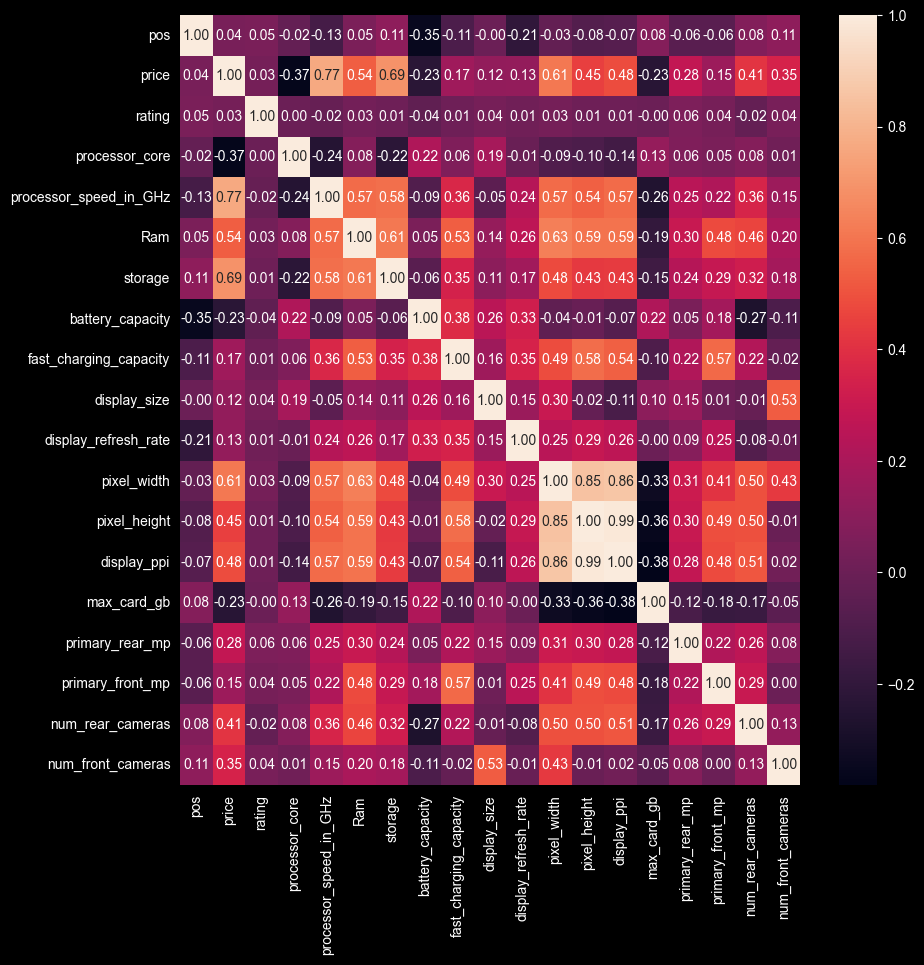

In [516]:
plt.figure(figsize=(10,10))
sns.heatmap(final_df.select_dtypes(include='number').corr(),annot=True,fmt='.2f')
plt.savefig('./plots/bivariate_analysis/price-corr/imputed_heatmap.png')

## price - processor_speed_in_GHz

In [7]:
df.columns

Index(['pos', 'brand', 'model', 'price', 'rating', 'Dual Sim', '3G', '4G',
       '5G', 'VoLTE', 'Vo5G', 'Wi-Fi', 'NFC', 'IR Blaster', 'processor_core',
       'processor_speed_in_GHz', 'Ram', 'storage', 'battery_capacity',
       'is_fast_charging', 'fast_charging_capacity', 'display_size',
       'display_refresh_rate', 'camera_notch_type', 'pixel_width',
       'pixel_height', 'display_ppi', 'os', 'is_memory_card_supported',
       'max_card_gb', 'primary_rear_mp', 'primary_front_mp',
       'num_rear_cameras', 'num_front_cameras', 'processor_brand',
       'processor_model'],
      dtype='str')

In [18]:
df[df['processor_brand'] == 'Unisoc']['brand'].value_counts()

brand
Lava        5
Ai+         4
Xiaomi      3
HMD         3
Motorola    2
Poco        2
Name: count, dtype: int64

## price - display_ppi
- phones below 30k have very poor ppi (bad display)

In [30]:
df['display_ppi'].describe()

count    902.000000
mean     389.962926
std       70.944925
min      253.630427
25%      384.657879
50%      394.573533
75%      449.839644
max      525.921017
Name: display_ppi, dtype: float64

<Axes: >

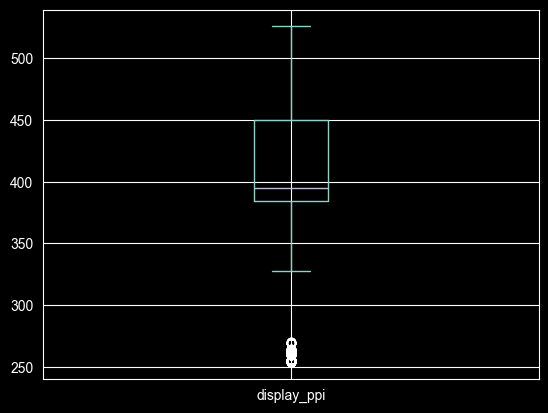

In [31]:
df['display_ppi'].plot(kind='box')

In [51]:
df[df['display_ppi'] >300]['display_ppi'].describe()

count    729.000000
mean     420.685046
std       36.015195
min      327.813567
25%      392.723643
50%      401.802361
75%      450.549868
max      525.921017
Name: display_ppi, dtype: float64

In [52]:
df[df['display_ppi'] <300]['price'].describe()

count      173.000000
mean     14975.861272
std       3986.624572
min       7499.000000
25%      12228.000000
50%      14470.000000
75%      16999.000000
max      29999.000000
Name: price, dtype: float64

In [54]:
df.groupby('brand')[['display_ppi','price']].describe()

display_ppi                                                 \
               count        mean        std         min         25%   
brand                                                                 
Acer             3.0  387.030215   0.000000  387.030215  387.030215   
Ai+              7.0  339.950619  99.621013  259.931404  260.124231   
Alcatel          2.0  329.653831  94.193425  263.049022  296.351426   
Apple           39.0  458.984597   2.013965  456.773482  457.563201   
CMF              4.0  391.120751   3.986930  387.667968  387.667968   
Google          18.0  442.244439  41.319772  372.369917  421.223787   
HMD              5.0  344.734909  71.631399  263.596016  269.129101   
Honor            4.0  430.129942  24.976338  394.440763  425.676986   
Infinix         26.0  376.484896  66.704797  259.931404  388.373692   
Lava            28.0  341.582736  67.717788  259.931404  259.931404   
Motorola        51.0  413.052925  43.284484  269.928766  394.573533   
Nothing         20.0  413.835011  29.731711  387.667968  387.850599   
OnePlus         41.0  449.873150  42.998492  387.667968  409.301005   
Oppo            90.0  363.438816  84.282137  255.884919  263.596016   
Poco            39.0  381.834304  74.330371  254.280721  373.508376   
Realme         139.0  384.970711  73.819644  253.630427  389.110185   
Samsung        127.0  389.860381  59.811000  260.317059  384.657879   
Tecno           25.0  362.409528  72.644793  255.557353  264.690690   
Vivo           129.0  380.035513  72.411483  255.884919  381.781091   
Wobble           3.0  330.270940   0.000000  330.270940  330.270940   
Xiaomi          61.0  384.397212  71.774770  254.280721  373.508376   
iQOO            39.0  406.694285  63.805343  260.317059  387.667968   
itel             2.0  263.869856   1.160835  263.049022  263.459439   

                                              price                 \
                 50%         75%         max  count           mean   
brand                                                                
Acer      387.030215  387.030215  387.030215    3.0   11329.333333   
Ai+       260.317059  444.658884  449.839644    7.0   18570.428571   
Alcatel   329.653831  362.956236  396.258640    2.0   13499.000000   
Apple     458.104148  460.516440  463.414035   39.0  113912.410256   
CMF       391.120751  394.573533  394.573533    4.0   18499.000000   
Google    430.038165  482.352941  512.877172   18.0   73057.500000   
HMD       394.573533  394.573533  401.802361    5.0   15320.800000   
Honor     436.664426  441.117382  452.750151    4.0   39499.000000   
Infinix   393.019999  428.744597  439.928150   26.0   20701.846154   
Lava      362.422236  394.573533  445.843486   28.0   14934.071429   
Motorola  413.386585  443.847172  464.652508   51.0   28763.725490   
Nothing   394.685118  442.334096  460.335788   20.0   34573.150000   
OnePlus   450.422677  459.903224  525.921017   41.0   43167.707317   
Oppo      394.440763  450.275776  460.143895   90.0   33240.688889   
Poco      395.675049  445.843486  460.349622   39.0   21220.461538   
Realme    394.573533  450.422677  508.219576  139.0   25335.251799   
Samsung   384.657879  402.688717  512.877172  127.0   48697.771654   
Tecno     393.019999  396.258640  451.087998   25.0   22107.320000   
Vivo      388.171897  452.867214  517.562530  129.0   33388.054264   
Wobble    330.270940  330.270940  330.270940    3.0   28332.333333   
Xiaomi    394.573533  445.843486  463.935861   61.0   26348.688525   
iQOO      392.723643  452.867214  517.562530   39.0   32333.051282   
itel      263.869856  264.280273  264.690690    2.0   10349.000000   

                                                                         
                   std      min      25%       50%        75%       max  
brand                                                                    
Acer       1531.456932   9990.0  10494.5   10999.0   11999.00   12999.0  
Ai+       14304.511443   8999.0  10999.0   12

## ppi - battery_capacity
- almost 50% phones have bare minimum (5000mAh) batter capacity for such high display_ppi  `(battery drains quickly)`

In [87]:
temp = df[df['display_ppi'] > 300]

In [64]:
temp['battery_capacity'].describe()

count      729.000000
mean      5544.572016
std       1028.016770
min       3149.000000
25%       5000.000000
50%       5110.000000
75%       6000.000000
max      10001.000000
Name: battery_capacity, dtype: float64

<Axes: xlabel='battery_capacity', ylabel='Count'>

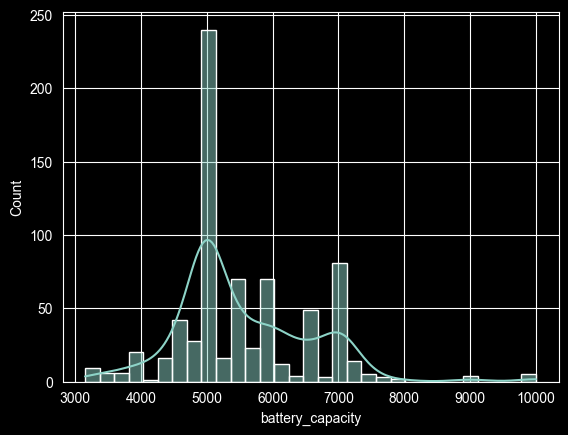

In [85]:
sns.histplot(data=temp,x='battery_capacity',kde=True)

## ppi - fast_charging_capacity
- most budget phones (<30k) don't have optimal fast charging capacity for such high ppi(>300)

In [61]:
temp['fast_charging_capacity'].describe()

count    729.000000
mean      59.132236
std       27.959831
min        0.000000
25%       33.000000
50%       50.000000
75%       80.000000
max      125.000000
Name: fast_charging_capacity, dtype: float64

In [67]:
temp[temp['fast_charging_capacity'] <50]['price'].describe()

count       361.000000
mean      38338.614958
std       36899.265063
min        9990.000000
25%       16999.000000
50%       21999.000000
75%       41999.000000
max      216999.000000
Name: price, dtype: float64

<Axes: xlabel='fast_charging_capacity', ylabel='Count'>

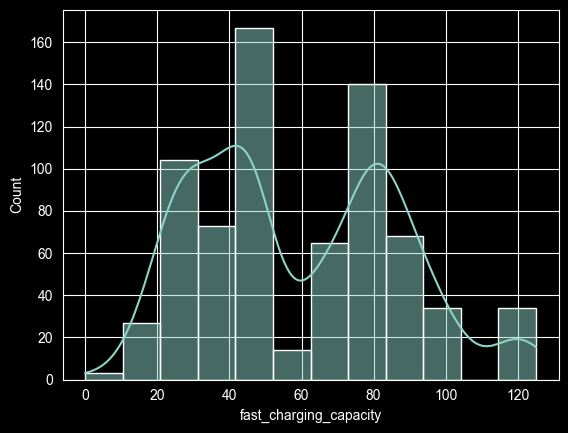

In [65]:
sns.histplot(data=temp,x='fast_charging_capacity',kde=True)

In [68]:
temp[temp['fast_charging_capacity'] >60]['price'].describe()

count       342.000000
mean      42747.792398
std       26768.438011
min       16999.000000
25%       27506.750000
50%       34994.500000
75%       46509.750000
max      189900.000000
Name: price, dtype: float64

<Axes: xlabel='display_ppi', ylabel='fast_charging_capacity'>

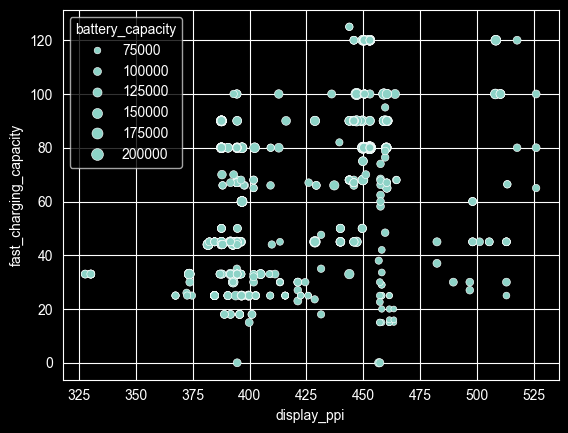

In [83]:
sns.scatterplot(data=temp,x='display_ppi',y='fast_charging_capacity',size=temp['battery_capacity']*20)

In [ ]:
temp[temp['fast_charging_capacity'] >60]

## battery_capacity vs fast_charging_capacity vs display_ppi
- majority smartphones with ppi >300 have battery_capacity <5000mah and fast_charging_capacity <55W.

Text(0.5, 0, 'fast_charging_capacity')

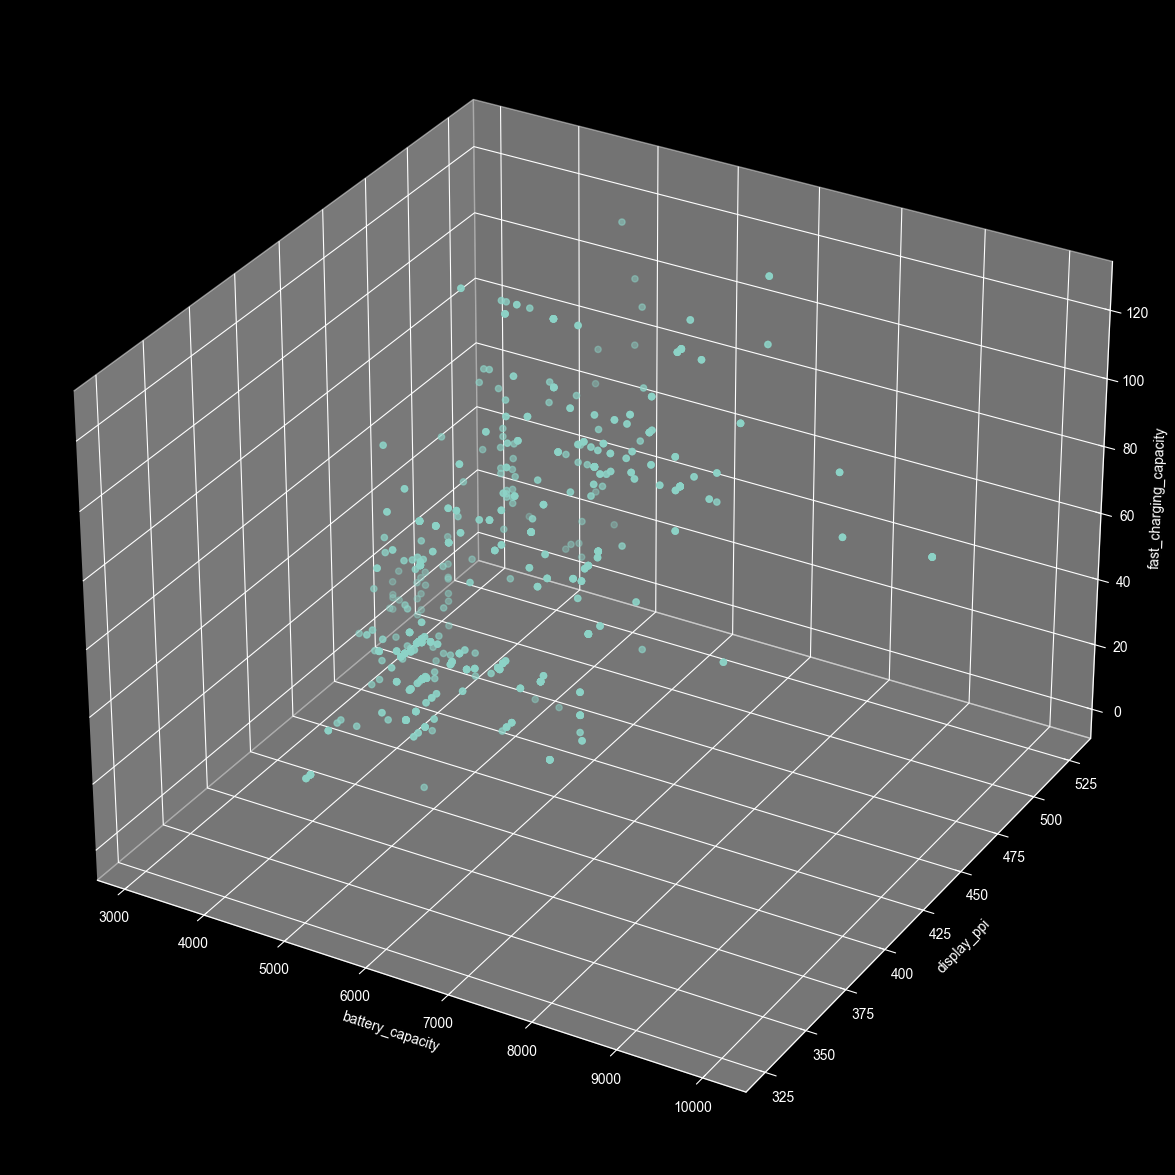

In [99]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(temp['battery_capacity'],temp['display_ppi'],temp['fast_charging_capacity'])
ax.set_xlabel('battery_capacity')
ax.set_ylabel('display_ppi')
ax.set_zlabel('fast_charging_capacity')
